# Task 8: Building the DNN

This notebook follows the Task 8 PDF in order and points to where each required step is implemented in the real code under `src/`.

## Imports and Project Path

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

root = Path.cwd()
while root != root.parent and not (root / 'src').exists():
    root = root.parent
if str(root / 'src') not in sys.path:
    sys.path.insert(0, str(root / 'src'))

from config import Stage1ModelConfig, Stage2ModelConfig, StageTrainingConfig, TwoStageRunConfig, TwoStageStackConfig
from datasets import build_two_stage_datasets
from measurements import (
    build_measurement_matrix,
    compute_gradient_data,
    measurement_points_on_unit_circle,
    measurements_to_feature_vector,
)
from models import (
    Stage1Regressor,
    denormalize_values,
    evaluate_regression_predictions,
    fit_stage1_model,
    normalize_values,
    predict_stage1_coefficients,
    predict_tensor,
)

np.random.seed(42)
torch.manual_seed(42)

## 1.0 Gradient Computation Function

Task 8 asks for a gradient computation function on unit-circle measurement points.

Where the real code does this:
- `src/measurements.py::measurement_points_on_unit_circle`
- `src/measurements.py::compute_gradient_data`

In [2]:
N = 3
measure_points = measurement_points_on_unit_circle(N + 1)
coefficients = np.array([1 + 0j, 0.2 + 0.1j, -0.1 + 0.05j, 0.03 - 0.02j])
gradient_data = compute_gradient_data(coefficients, measure_points, N)
print('Complex gradient shape:', gradient_data.shape)
gradient_data

Complex gradient shape: (4,)


array([ 2.26-0.26j, -0.44+2.44j, -1.34-0.06j, -0.24-1.96j])

## 1.0.3 Relationship to the Measurement Matrix

Task 8 also gives the matrix view of the same measurement process.

Where the real code does this:
- `src/measurements.py::build_measurement_matrix`

In [3]:
measurement_matrix = build_measurement_matrix(measure_points, N)
print('Measurement matrix shape:', measurement_matrix.shape)
print('Condition number:', np.linalg.cond(measurement_matrix))
measurement_matrix

Measurement matrix shape: (4, 4)
Condition number: 1.0000000000000004


array([[ 2.00000000e+00+0.00000000e+00j,  2.00000000e+00+0.00000000e+00j,
         2.00000000e+00+0.00000000e+00j,  2.00000000e+00+0.00000000e+00j],
       [ 1.22464680e-16+2.00000000e+00j, -2.00000000e+00+2.44929360e-16j,
        -3.67394040e-16-2.00000000e+00j,  2.00000000e+00-4.89858720e-16j],
       [-2.00000000e+00+2.44929360e-16j,  2.00000000e+00-4.89858720e-16j,
        -2.00000000e+00+7.34788079e-16j,  2.00000000e+00-9.79717439e-16j],
       [-3.67394040e-16-2.00000000e+00j, -2.00000000e+00+7.34788079e-16j,
         1.10218212e-15+2.00000000e+00j,  2.00000000e+00-1.46957616e-15j]])

## 1.0.4 Data Representation

Task 8 converts complex gradient values into a real vector `[real, imag]` for neural-network input.

Where the real code does this:
- `src/measurements.py::measurements_to_feature_vector`

In [4]:
gradient_data_real = measurements_to_feature_vector(gradient_data)
print('Real-valued gradient shape:', gradient_data_real.shape)
gradient_data_real

Real-valued gradient shape: (8,)


array([ 2.26, -0.44, -1.34, -0.24, -0.26,  2.44, -0.06, -1.96],
      dtype=float32)

## 2.0 DNN Training

Task 8 says Stage 1 should take noisy gradient data and predict the real and imaginary parts of the coefficients. This notebook now uses one canonical Task 8-aligned run so we can judge whether the Task 8 model is the right Stage 1 model for the project.

Where the real code does this:
- `src/pipeline/run.py::run_two_stage_once`
- `src/models/stage1/model.py::Stage1Regressor`
- `src/models/stage1/train.py::fit_stage1_model`

In [5]:
# This is the canonical Task 8 Stage 1 demo run for the project.
# It keeps the Task 8 model and Task 8 training hyperparameters, but uses
# moderate N and dataset sizes so we can clearly see whether the model learns.
demo_run = TwoStageRunConfig(
    N=4,
    training_samples=4000,
    validation_samples=1000,
    test_samples=500,
    grid_size=32,
    model=TwoStageStackConfig(
        stage1=Stage1ModelConfig(
            hidden_layer_sizes=(128, 256, 128),
            dropout_rates=(0.2, 0.2, 0.2),
            training=StageTrainingConfig(
                epochs=200,
                batch_size=32,
                learning_rate=0.0005,
                validation_frequency=10,
                verbose=True,
                early_stopping_patience=10,
            ),
        ),
        stage2=Stage2ModelConfig(
            hidden_layer_sizes=(256, 256),
            training=StageTrainingConfig(
                epochs=1,
                batch_size=32,
                learning_rate=0.0005,
                validation_frequency=10,
                verbose=False,
                early_stopping_patience=None,
            ),
        ),
    ),
)

# Noise is being added here via the function
# From src/datasets/builder.py, where the dataset builder adds synthetic noise
dataset_bundle = build_two_stage_datasets(demo_run)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Train gradient data shape:', dataset_bundle.train.gradient_data.shape)
print('Train coefficient target shape:', dataset_bundle.train.coefficients.shape)
print('Stage 1 Task 8 training config:', demo_run.model.stage1.training)

Train gradient data shape: (4000, 10)
Train coefficient target shape: (4000, 10)
Stage 1 Task 8 training config: StageTrainingConfig(epochs=200, batch_size=32, learning_rate=0.0005, validation_frequency=10, verbose=True, early_stopping_patience=10, min_epochs=None, min_improvement=None, lr_drop_factor=None, lr_drop_period=None, weight_decay=0.0, gradient_clip_norm=None, loss_type='bce', dice_loss_weight=0.0, dice_smooth=1.0)


## 2.2.1 Target Normalization

Task 8 normalizes the output coefficients using training-set mean and standard deviation.

Where the real code does this:
- `src/models/common_train.py::compute_target_normalization`
- `src/models/common_train.py::normalize_values`
- `src/models/stage1/train.py::fit_stage1_model`

In [6]:
Y_mu = dataset_bundle.train.coefficients.mean(axis=0)
Y_sigma = dataset_bundle.train.coefficients.std(axis=0)
Y_sigma = np.where(Y_sigma == 0, 1.0, Y_sigma)
Y_train_norm = normalize_values(dataset_bundle.train.coefficients, Y_mu, Y_sigma)
Y_val_norm = normalize_values(dataset_bundle.validation.coefficients, Y_mu, Y_sigma)
print('Y_mu shape:', Y_mu.shape)
print('Y_sigma shape:', Y_sigma.shape)
print('Normalized training targets shape:', Y_train_norm.shape)
print('Normalized validation targets shape:', Y_val_norm.shape)

Y_mu shape: (10,)
Y_sigma shape: (10,)
Normalized training targets shape: (4000, 10)
Normalized validation targets shape: (1000, 10)


## 2.2.2 Input Normalization

Task 8 normalizes the gradient-measurement inputs with z-score normalization.

Where the real code does this:
- `src/models/common_train.py::compute_input_normalization`
- `src/models/common_train.py::normalize_values`
- `src/models/stage1/train.py::fit_stage1_model`

In [7]:
X_mu = dataset_bundle.train.gradient_data.mean(axis=0)
X_sigma = dataset_bundle.train.gradient_data.std(axis=0)
X_sigma = np.where(X_sigma == 0, 1.0, X_sigma)
X_train_norm = normalize_values(dataset_bundle.train.gradient_data, X_mu, X_sigma)
X_val_norm = normalize_values(dataset_bundle.validation.gradient_data, X_mu, X_sigma)
print('X_mu shape:', X_mu.shape)
print('X_sigma shape:', X_sigma.shape)
print('Normalized training inputs shape:', X_train_norm.shape)
print('Normalized validation inputs shape:', X_val_norm.shape)

X_mu shape: (10,)
X_sigma shape: (10,)
Normalized training inputs shape: (4000, 10)
Normalized validation inputs shape: (1000, 10)


## 2.3 DNN Architecture

Task 8 uses a `128 -> 256 -> 128` fully connected DNN with ReLU and dropout. This is the same Stage 1 architecture used by the project.

Where the real code does this:
- `src/models/common.py::build_mlp_with_dropout`
- `src/models/stage1/model.py::Stage1Regressor`
- `src/config/model_stack.py::TwoStageStackConfig`

In [8]:
stage1_model = Stage1Regressor(
    input_dim=demo_run.gradient_feature_size,
    output_dim=demo_run.coefficient_size,
    hidden_dims=demo_run.model.stage1.hidden_layer_sizes,
    dropout_rates=demo_run.model.stage1.dropout_rates,
)
print(stage1_model)

Stage1Regressor(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 2.4.1 Training Options

Task 8 training options and where they live now. The canonical notebook run uses these same Stage 1 hyperparameters directly:
- `adam` -> `src/models/stage1/train.py::_fit_stage1_model`
- `MaxEpochs` -> `src/config/training.py::StageTrainingConfig.epochs`
- `MiniBatchSize` -> `src/config/training.py::StageTrainingConfig.batch_size`
- `Shuffle = every-epoch` -> `src/models/common_train.py::_to_loader`
- `ValidationData` -> `src/pipeline/run.py::run_two_stage_once` and this notebook's `fit_stage1_model(...)` call
- `ValidationFrequency` -> `src/config/training.py::StageTrainingConfig.validation_frequency` and `src/models/stage1/train.py::_fit_stage1_model`
- `InitialLearnRate` -> `src/config/training.py::StageTrainingConfig.learning_rate`
- `Verbose` -> `src/config/training.py::StageTrainingConfig.verbose` and `src/models/stage1/train.py::_fit_stage1_model`
- `OutputFcn @(info) stopIfOverfitting(info, 10)` -> `src/models/stage1/train.py::stop_if_overfitting`
- `Plots = training-progress` -> handled differently; loss history is stored in `src/models/common_train.py::ModelTrainingResult.history`

In [9]:
stage1_training = demo_run.model.stage1.training
print('Optimizer: Adam')
print('Max epochs:', stage1_training.epochs)
print('Mini-batch size:', stage1_training.batch_size)
print('Validation frequency:', stage1_training.validation_frequency)
print('Initial learning rate:', stage1_training.learning_rate)
print('Verbose:', stage1_training.verbose)
print('Early stopping patience:', stage1_training.early_stopping_patience)

Optimizer: Adam
Max epochs: 200
Mini-batch size: 32
Validation frequency: 10
Initial learning rate: 0.0005
Verbose: True
Early stopping patience: 10


## 2.4.2 Training Execution

Task 8 trains the DNN and stores the learned normalization values on the trained model object. In the real code, the network stays in `stage1_model` and the learned normalization values are stored in the returned `stage1_result`.

Where the real code does this:
- `src/models/stage1/train.py::fit_stage1_model`

In [10]:
stage1_result = fit_stage1_model(
    model=stage1_model,
    train_features=dataset_bundle.train.gradient_data,
    train_targets=dataset_bundle.train.coefficients,
    val_features=dataset_bundle.validation.gradient_data,
    val_targets=dataset_bundle.validation.coefficients,
    epochs=stage1_training.epochs,
    batch_size=stage1_training.batch_size,
    learning_rate=stage1_training.learning_rate,
    device=device,
    validation_frequency=stage1_training.validation_frequency,
    verbose=stage1_training.verbose,
    early_stopping_patience=stage1_training.early_stopping_patience,
)
print('Stored X_mu shape:', stage1_result.input_mean.shape)
print('Stored X_sigma shape:', stage1_result.input_std.shape)
print('Stored Y_mu shape:', stage1_result.target_mean.shape)
print('Stored Y_sigma shape:', stage1_result.target_std.shape)

Epoch 1/200 | step 10 | train_loss=0.833958 | val_loss=0.884524
Epoch 1/200 | step 20 | train_loss=0.918377 | val_loss=0.802862
Epoch 1/200 | step 30 | train_loss=0.826534 | val_loss=0.709600
Epoch 1/200 | step 40 | train_loss=0.781528 | val_loss=0.594516
Epoch 1/200 | step 50 | train_loss=0.754173 | val_loss=0.494323
Epoch 1/200 | step 60 | train_loss=0.719026 | val_loss=0.425318
Epoch 1/200 | step 70 | train_loss=0.675822 | val_loss=0.385252
Epoch 1/200 | step 80 | train_loss=0.645567 | val_loss=0.340578
Epoch 1/200 | step 90 | train_loss=0.616300 | val_loss=0.308391
Epoch 1/200 | step 100 | train_loss=0.589559 | val_loss=0.282613
Epoch 1/200 | step 110 | train_loss=0.565495 | val_loss=0.268477
Epoch 1/200 | step 120 | train_loss=0.544838 | val_loss=0.235102
Epoch 2/200 | step 130 | train_loss=0.259243 | val_loss=0.212683
Epoch 2/200 | step 140 | train_loss=0.270712 | val_loss=0.192376
Epoch 2/200 | step 150 | train_loss=0.274140 | val_loss=0.173722
Epoch 2/200 | step 160 | train_los

## 2.5 Validation and Error Analysis

Task 8 predicts on the validation set, de-normalizes the outputs, and computes validation MSE.

Where the real code does this:
- normalization and de-normalization helpers: `src/models/common_train.py::normalize_values` and `src/models/common_train.py::denormalize_values`
- raw prediction helper: `src/models/common_train.py::predict_tensor`

In [11]:
X_val_norm = normalize_values(
    dataset_bundle.validation.gradient_data,
    stage1_result.input_mean,
    stage1_result.input_std,
)
Y_pred_norm = predict_tensor(stage1_model, X_val_norm, device=device)
Y_pred_denorm = denormalize_values(
    Y_pred_norm,
    stage1_result.target_mean,
    stage1_result.target_std,
)
val_error = np.mean((Y_pred_denorm - dataset_bundle.validation.coefficients) ** 2)
print(f'DNN Validation MSE: {val_error:.6f}')

DNN Validation MSE: 0.000036


## 2.7.1 Generating Predictions for MLP Training

Task 8 stores de-normalized predicted coefficients back onto the training and validation datasets.

Where the real code does this conceptually:
- manual notebook version below
- reusable helper version: `src/models/stage1/train.py::predict_stage1_coefficients`

In [12]:
# Task 8 MATLAB equivalent: X_train_norm = (trainingData.gradData - dnnModel.X_mu) ./ dnnModel.X_sigma
X_train_norm = normalize_values(dataset_bundle.train.gradient_data, stage1_result.input_mean, stage1_result.input_std)
train_pred_norm = predict_tensor(stage1_model, X_train_norm, device=device)
dataset_bundle.train.dnnPredictedCoeffs = denormalize_values(
    train_pred_norm,
    stage1_result.target_mean,
    stage1_result.target_std,
)

# Task 8 MATLAB equivalent: X_val_norm = (validationData.gradData - dnnModel.X_mu) ./ dnnModel.X_sigma
X_val_norm = normalize_values(dataset_bundle.validation.gradient_data, stage1_result.input_mean, stage1_result.input_std)
val_pred_norm = predict_tensor(stage1_model, X_val_norm, device=device)
dataset_bundle.validation.dnnPredictedCoeffs = denormalize_values(
    val_pred_norm,
    stage1_result.target_mean,
    stage1_result.target_std,
)

helper_train_predictions = predict_stage1_coefficients(
    stage1_model,
    dataset_bundle.train.gradient_data,
    device=device,
    training_result=stage1_result,
)
print('Stored training prediction shape:', dataset_bundle.train.dnnPredictedCoeffs.shape)
print('Stored validation prediction shape:', dataset_bundle.validation.dnnPredictedCoeffs.shape)
print('Matches helper exactly:', np.allclose(dataset_bundle.train.dnnPredictedCoeffs, helper_train_predictions))

Stored training prediction shape: (4000, 10)
Stored validation prediction shape: (1000, 10)
Matches helper exactly: True


## 2.8 Training Diagnostics

Task 8 mentions training loss, validation loss, validation frequency, and early stopping. In the real code, these diagnostics are stored in the training history object.

Where the real code does this:
- `src/models/common_train.py::ModelTrainingResult.history`
- validation scheduling: `src/models/stage1/train.py::_fit_stage1_model`
- early stopping helper: `src/models/stage1/train.py::stop_if_overfitting`

In [13]:
print('Training loss history:', stage1_result.history['train_loss'])
print('Validation loss history:', stage1_result.history['val_loss'])
print('Validation steps:', stage1_result.history['validation_steps'])

Training loss history: [0.534797957956791, 0.2119182370901108, 0.1423855282664299, 0.11655460050702095, 0.10290054115653038, 0.09910041593453463]
Validation loss history: [0.8845236143097281, 0.8028621422126889, 0.7096000267192721, 0.5945156342349946, 0.49432301288470626, 0.4253179472871125, 0.3852516277693212, 0.3405775830615312, 0.30839106044732034, 0.2826130357570946, 0.2684773663058877, 0.23510226793587208, 0.21268309652805328, 0.19237596075981855, 0.17372217844240367, 0.16897886921651661, 0.15311222290620208, 0.13556448800954968, 0.1278476476436481, 0.1190487751737237, 0.11797107267193496, 0.10841587744653225, 0.0999611500883475, 0.09025256906170398, 0.08695002732565627, 0.08996507804840803, 0.08389407774666324, 0.07468824117677286, 0.06736646068748087, 0.07306900311959907, 0.07574754685629159, 0.07132991490652785, 0.06655933713773265, 0.05807574902428314, 0.05819230852648616, 0.05719236592995003, 0.05771401722449809, 0.05658485181629658, 0.05743298400193453, 0.058650103921536356,

## 2.8.2 Performance Metrics and End-to-End Check

Task 8 calls out validation MSE, training MSE, and overfitting diagnostics. This cell gives a compact end-to-end performance check using the reusable helper path.

Where the real code does this:
- `src/models/stage1/train.py::predict_stage1_coefficients`
- `src/models/metrics.py::evaluate_regression_predictions`
- full reusable entry point: `src/pipeline/run.py::run_two_stage_once`

In [14]:
predicted_validation_coefficients = predict_stage1_coefficients(
    stage1_model,
    dataset_bundle.validation.gradient_data,
    device=device,
    training_result=stage1_result,
)
validation_metrics = evaluate_regression_predictions(
    dataset_bundle.validation.coefficients,
    predicted_validation_coefficients,
)
print('Validation regression metrics:', validation_metrics)
# full_summary = run_two_stage_once(demo_run)

Validation regression metrics: {'mse': 3.568298780010082e-05, 'mae': 0.0018861335702240467}


## 2.8.3 Stage 1 Performance Graphs

These plots are the notebook equivalent of the Task 8 training-progress view and coefficient-quality checks. They now visualize the single canonical Task 8 run used throughout this notebook.

In [15]:
# Plot the Stage 1 training and validation loss histories.
# We use separate subplots because training loss is stored once per epoch,
# while validation loss is stored every time validation is checked.
def plot_stage1_loss_history(stage1_result):
    history = stage1_result.history
    epochs = np.arange(1, len(history['train_loss']) + 1)
    validation_steps = np.array(history['validation_steps'])

    fig, axes = plt.subplots(2, 1, figsize=(8, 7))
    axes[0].plot(epochs, history['train_loss'], marker='o', label='train loss')
    axes[0].set_title('Stage 1 Training Loss by Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE loss')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(validation_steps, history['val_loss'], marker='o', color='tab:orange', label='validation loss')
    axes[1].set_title('Stage 1 Validation Loss by Validation Step')
    axes[1].set_xlabel('Validation step')
    axes[1].set_ylabel('MSE loss')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    plt.show()

# Plot the average absolute error for each coefficient feature.
# This shows which real/imag coefficient components are easier or harder
# for the Stage 1 DNN to predict.
def plot_stage1_coefficient_error_bar(y_true, y_pred):
    mean_absolute_error_by_feature = np.abs(y_pred - y_true).mean(axis=0)

    plt.figure(figsize=(10, 4))
    plt.bar(np.arange(len(mean_absolute_error_by_feature)), mean_absolute_error_by_feature)
    plt.title('Stage 1 Mean Absolute Error by Coefficient Feature')
    plt.xlabel('Coefficient feature index')
    plt.ylabel('Mean absolute error')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

# Plot true-vs-predicted coefficient values for a few feature indices.
# Points near the diagonal line indicate accurate coefficient prediction.
def plot_stage1_true_vs_pred_scatter(y_true, y_pred, feature_indices=(0, 1, 2)):
    fig, axes = plt.subplots(1, len(feature_indices), figsize=(5 * len(feature_indices), 4))
    if len(feature_indices) == 1:
        axes = [axes]

    for axis, feature_index in zip(axes, feature_indices):
        true_values = y_true[:, feature_index]
        predicted_values = y_pred[:, feature_index]
        lower_bound = min(true_values.min(), predicted_values.min())
        upper_bound = max(true_values.max(), predicted_values.max())

        axis.scatter(true_values, predicted_values, alpha=0.75)
        axis.plot([lower_bound, upper_bound], [lower_bound, upper_bound], linestyle='--', color='red')
        axis.set_title(f'Feature {feature_index}: True vs Predicted')
        axis.set_xlabel('True value')
        axis.set_ylabel('Predicted value')
        axis.grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()

# Print a few side-by-side coefficient examples so the demo can show
# the exact numbers the network is getting right or wrong.
def show_stage1_coefficient_examples(y_true, y_pred, sample_count=3):
    for sample_index in range(min(sample_count, y_true.shape[0])):
        print(f'Sample {sample_index}')
        print('True:      ', np.round(y_true[sample_index], 4))
        print('Predicted: ', np.round(y_pred[sample_index], 4))
        print('Abs error: ', np.round(np.abs(y_pred[sample_index] - y_true[sample_index]), 4))
        print()

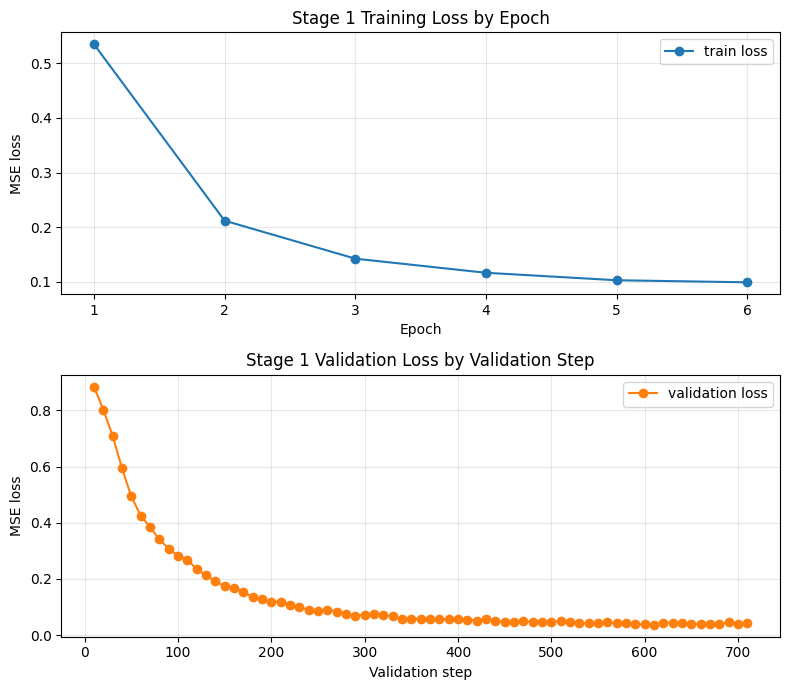

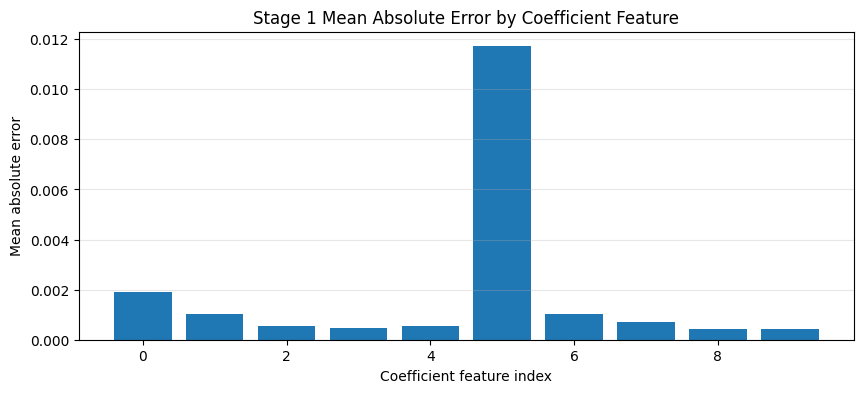

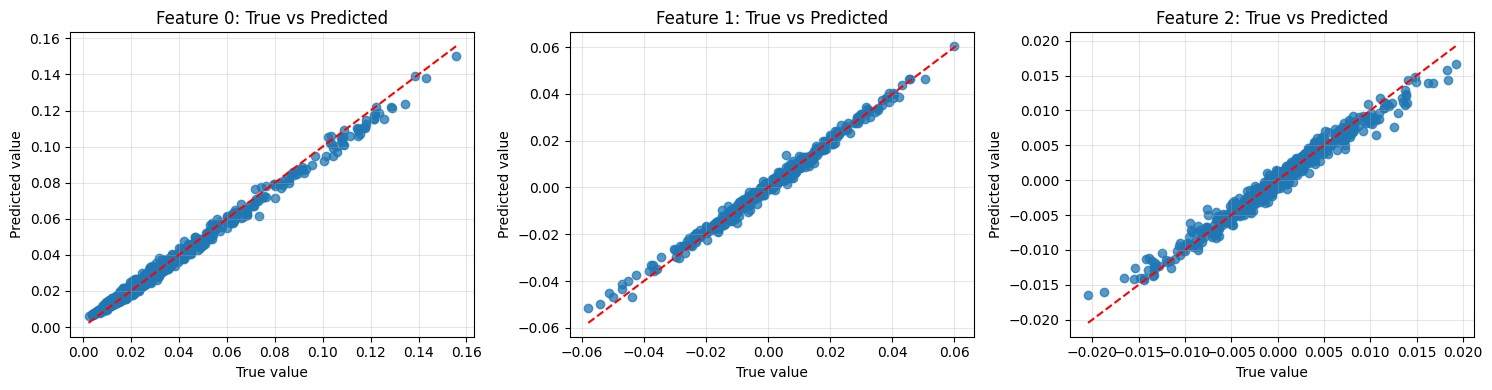

Sample 0
True:       [ 0.0136 -0.0009  0.0006 -0.0005  0.0001  0.     -0.0018 -0.0005 -0.
  0.    ]
Predicted:  [ 0.014  -0.0005  0.0002 -0.0003  0.0002 -0.0023 -0.0008 -0.0001  0.0001
 -0.0001]
Abs error:  [0.0004 0.0004 0.0003 0.0002 0.0001 0.0023 0.0011 0.0004 0.0001 0.0001]

Sample 1
True:       [ 0.0288 -0.0049 -0.0049  0.0024  0.0005  0.     -0.001  -0.0013  0.0017
 -0.0002]
Predicted:  [ 0.0298 -0.003  -0.0032  0.0016  0.0003 -0.0042 -0.0017 -0.0005  0.0017
 -0.0007]
Abs error:  [0.001  0.002  0.0017 0.0008 0.0002 0.0042 0.0008 0.0008 0.0001 0.0004]

Sample 2
True:       [ 0.0229 -0.0005  0.0003  0.0001 -0.0001  0.      0.0006 -0.0011  0.0001
 -0.    ]
Predicted:  [ 0.0205 -0.0005  0.0001  0.0001  0.0001 -0.0008  0.0008 -0.0006  0.0001
 -0.    ]
Abs error:  [0.0023 0.     0.0002 0.     0.0002 0.0008 0.0002 0.0004 0.     0.    ]



In [16]:
# Use validation data here because Task 8 evaluates held-out validation
# performance after training. These plots show both optimization progress
# and how accurately Stage 1 predicts the coefficient features.
plot_stage1_loss_history(stage1_result)
plot_stage1_coefficient_error_bar(
    dataset_bundle.validation.coefficients,
    predicted_validation_coefficients,
)
plot_stage1_true_vs_pred_scatter(
    dataset_bundle.validation.coefficients,
    predicted_validation_coefficients,
    feature_indices=(0, 1, 2),
)
show_stage1_coefficient_examples(
    dataset_bundle.validation.coefficients,
    predicted_validation_coefficients,
    sample_count=3,
)